In [55]:
!pip install kagglehub pandas numpy scikit-learn catboost lightgbm xgboost -q

In [56]:
import kagglehub
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [59]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

In [60]:
!pip install openpyxl -q

In [61]:
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

In [62]:
print("Скачивание датасета...")

Скачивание датасета...


In [63]:
print("Скачивание датасета...")
path = kagglehub.dataset_download("sinamhd9/concrete-comprehensive-strength")
print("Путь к файлам датасета:", path)


Скачивание датасета...
Using Colab cache for faster access to the 'concrete-comprehensive-strength' dataset.
Путь к файлам датасета: /kaggle/input/concrete-comprehensive-strength


In [64]:
print("Содержимое папки:")
for file in os.listdir(path):
    print(" -", file)

Содержимое папки:
 - Concrete_Data.xls


In [65]:
data_files = []
for f in os.listdir(path):
    f_lower = f.lower()
    if f_lower.endswith(('.csv', '.xls', '.xlsx', '.data', '.txt')):
        data_files.append(f)

if not data_files:
    raise FileNotFoundError("Не найден файл данных в поддерживаемом формате.")

In [66]:
data_file = data_files[0]
print(f"Найден файл данных: {data_file}")

file_path = os.path.join(path, data_file)

Найден файл данных: Concrete_Data.xls


In [67]:
if data_file.lower().endswith(('.xls', '.xlsx')):
  try:
        df = pd.read_excel(file_path)
  except ImportError:
        print("Устанавливаем openpyxl для чтения Excel...")
        !pip install openpyxl -q
        df = pd.read_excel(file_path)
else:
    df = pd.read_csv(file_path)

print(f"\nРазмер датасета: {df.shape}")
print(f"Колонки: {df.columns.tolist()}")


Размер датасета: (1030, 9)
Колонки: ['Cement (component 1)(kg in a m^3 mixture)', 'Blast Furnace Slag (component 2)(kg in a m^3 mixture)', 'Fly Ash (component 3)(kg in a m^3 mixture)', 'Water  (component 4)(kg in a m^3 mixture)', 'Superplasticizer (component 5)(kg in a m^3 mixture)', 'Coarse Aggregate  (component 6)(kg in a m^3 mixture)', 'Fine Aggregate (component 7)(kg in a m^3 mixture)', 'Age (day)', 'Concrete compressive strength(MPa, megapascals) ']


In [68]:
ppossible_target = [col for col in df.columns if 'strength' in col.lower()]
if len(possible_target) == 1:
    target_col = possible_target[0]
    print(f"Найдена целевая переменная: '{target_col}'")
else:
    print("Не удалось однозначно определить целевую переменную.")
    print("Доступные колонки:", df.columns.tolist())
    target_col = input("Введите название столбца с целевой переменной: ").strip()

Найдена целевая переменная: 'Concrete compressive strength(MPa, megapascals) '


In [69]:
print("\n--- Первичный анализ данных ---")
print("\nПервые 5 строк:")
df.head()

print("\nИнформация о данных:")
df.info()

print("\nОписательная статистика:")
df.describe()

print("\nПроверка пропусков:")
print(df.isnull().sum())


--- Первичный анализ данных ---

Первые 5 строк:

Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 n

Text(0.5, 1.0, 'Boxplot Concrete compressive strength(MPa, megapascals) ')

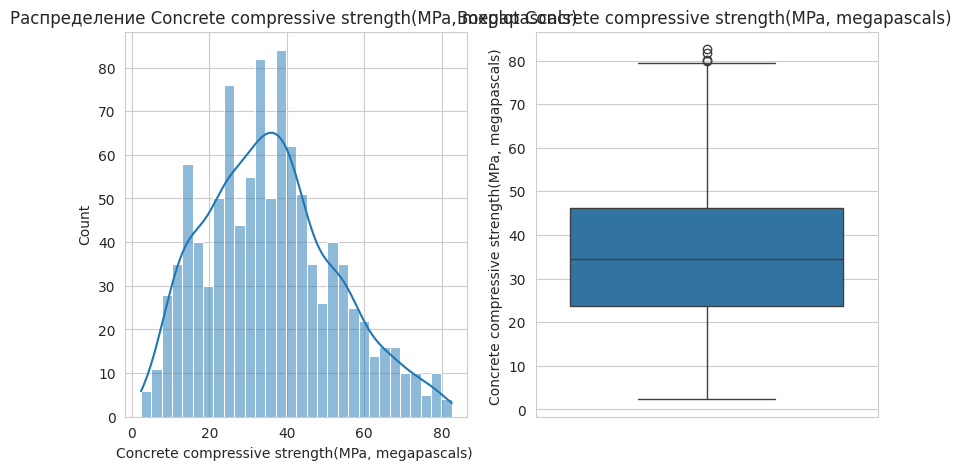

In [70]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(df[target_col], kde=True, bins=30)
plt.title(f'Распределение {target_col}')

plt.subplot(1, 3, 2)
sns.boxplot(y=df[target_col])
plt.title(f'Boxplot {target_col}')

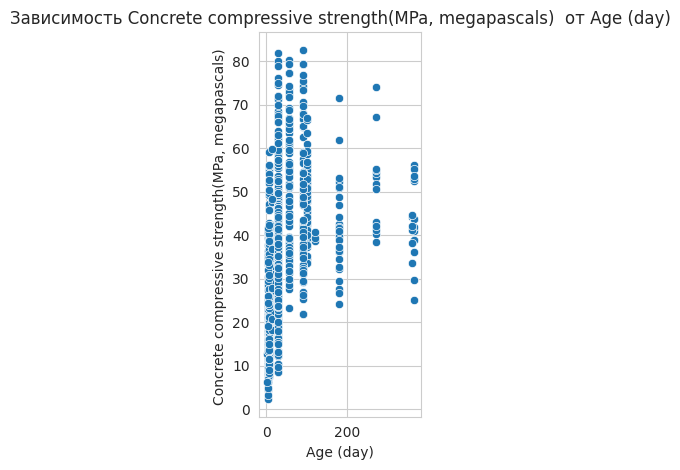

In [71]:
age_col = [col for col in df.columns if 'age' in col.lower()]
if age_col:
    age_col = age_col[0]
    plt.subplot(1, 3, 3)
    sns.scatterplot(x=df[age_col], y=df[target_col])
    plt.title(f'Зависимость {target_col} от {age_col}')

plt.tight_layout()
plt.show()

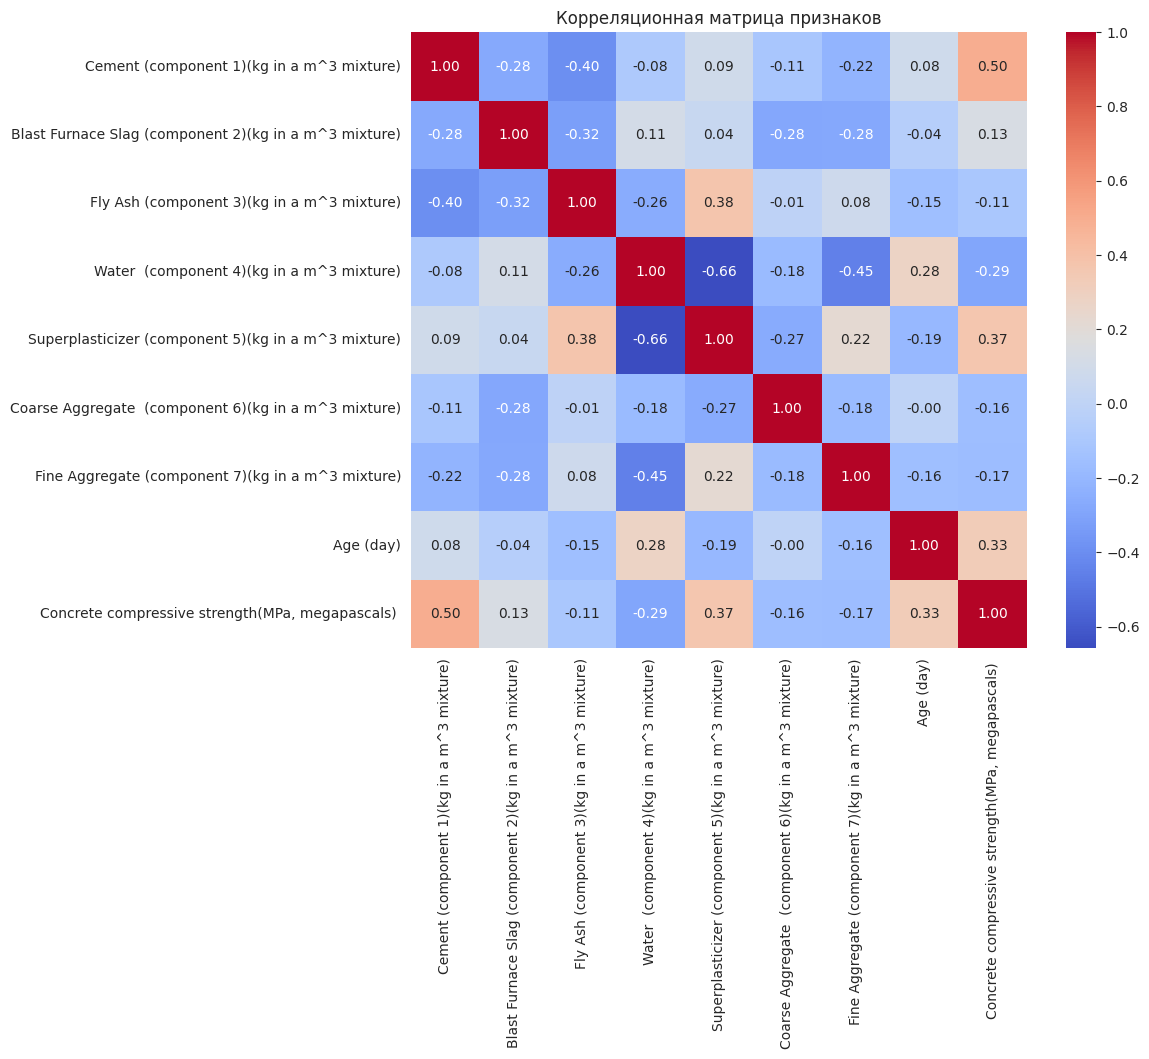

In [72]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица признаков')
plt.show()


In [73]:
X = df.drop(target_col, axis=1)
y = df[target_col]

print(f"\nПризнаки (X): {X.shape}")
print(f"Целевая переменная (y): {y.shape}")



Признаки (X): (1030, 8)
Целевая переменная (y): (1030,)


In [74]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nМасштабирование завершено.")
print(X_scaled.head())


Масштабирование завершено.
   Cement (component 1)(kg in a m^3 mixture)  \
0                                   2.477918   
1                                   2.477918   
2                                   0.491443   
3                                   0.491443   
4                                  -0.790432   

   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  \
0                                          -0.856886       
1                                          -0.856886       
2                                           0.795533       
3                                           0.795533       
4                                           0.678414       

   Fly Ash (component 3)(kg in a m^3 mixture)  \
0                                   -0.847132   
1                                   -0.847132   
2                                   -0.847132   
3                                   -0.847132   
4                                   -0.847132   

   Water  (component 4)(kg 

In [75]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (824, 8)
Размер тестовой выборки: (206, 8)


In [76]:
results = {'Model': [], 'R2 Score': [], 'RMSE': [], 'MAE': [], 'CV R2 Mean': []}

models = {
    'Linear Regression': LinearRegression(),
    'Lasso': Lasso(random_state=42),
    'Ridge': Ridge(random_state=42),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_jobs=-1),
    'SVR': SVR(kernel='rbf'),
    'XGBoost': XGBRegressor(random_state=42, eval_metric='rmse'),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_state=42, verbose=0)
}

print("\n" + "="*70)
print("Начало обучения и оценки моделей...")
print("="*70)


Начало обучения и оценки моделей...


In [77]:
for name, model in models.items():
    print(f"\n--- Обучение модели: {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_scaled, y, cv=cv, scoring='r2', n_jobs=-1)

    results['Model'].append(name)
    results['R2 Score'].append(round(r2, 4))
    results['RMSE'].append(round(rmse, 4))
    results['MAE'].append(round(mae, 4))
    results['CV R2 Mean'].append(round(cv_scores.mean(), 4))

    print(f"  R² на тесте: {r2:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE: {mae:.4f}")
    print(f"  Средний R² (CV): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values(by='R2 Score', ascending=False).reset_index(drop=True)
print("\n" + "="*70)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*70)
results_df


--- Обучение модели: Linear Regression ---
  R² на тесте: 0.6275
  RMSE: 9.7967
  MAE: 7.7454
  Средний R² (CV): 0.6006 (+/- 0.0478)

--- Обучение модели: Lasso ---
  R² на тесте: 0.5635
  RMSE: 10.6052
  MAE: 8.7211
  Средний R² (CV): 0.5580 (+/- 0.0294)

--- Обучение модели: Ridge ---
  R² на тесте: 0.6276
  RMSE: 9.7963
  MAE: 7.7517
  Средний R² (CV): 0.6007 (+/- 0.0475)

--- Обучение модели: Decision Tree ---
  R² на тесте: 0.7917
  RMSE: 7.3262
  MAE: 4.5913
  Средний R² (CV): 0.8417 (+/- 0.0320)

--- Обучение модели: Random Forest ---
  R² на тесте: 0.8819
  RMSE: 5.5167
  MAE: 3.7613
  Средний R² (CV): 0.9059 (+/- 0.0167)

--- Обучение модели: SVR ---
  R² на тесте: 0.6480
  RMSE: 9.5240
  MAE: 7.5668
  Средний R² (CV): 0.6476 (+/- 0.0298)

--- Обучение модели: XGBoost ---
  R² на тесте: 0.9231
  RMSE: 4.4522
  MAE: 2.9068
  Средний R² (CV): 0.9217 (+/- 0.0046)

--- Обучение модели: LightGBM ---
  R² на тесте: 0.9143
  RMSE: 4.7002
  MAE: 3.1840
  Средний R² (CV): 0.9234 (+/- 

,Model,R2 Score,RMSE,MAE,CV R2 Mean
0,CatBoost,0.9343,4.1131,2.7046,0.9418
1,XGBoost,0.9231,4.4522,2.9068,0.9217
2,LightGBM,0.9143,4.7002,3.1840,0.9234
3,Random Forest,0.8819,5.5167,3.7613,0.9059
4,Decision Tree,0.7917,7.3262,4.5913,0.8417
5,SVR,0.6480,9.5240,7.5668,0.6476
6,Ridge,0.6276,9.7963,7.7517,0.6007
7,Linear Regression,0.6275,9.7967,7.7454,0.6006
8,Lasso,0.5635,10.6052,8.7211,0.5580


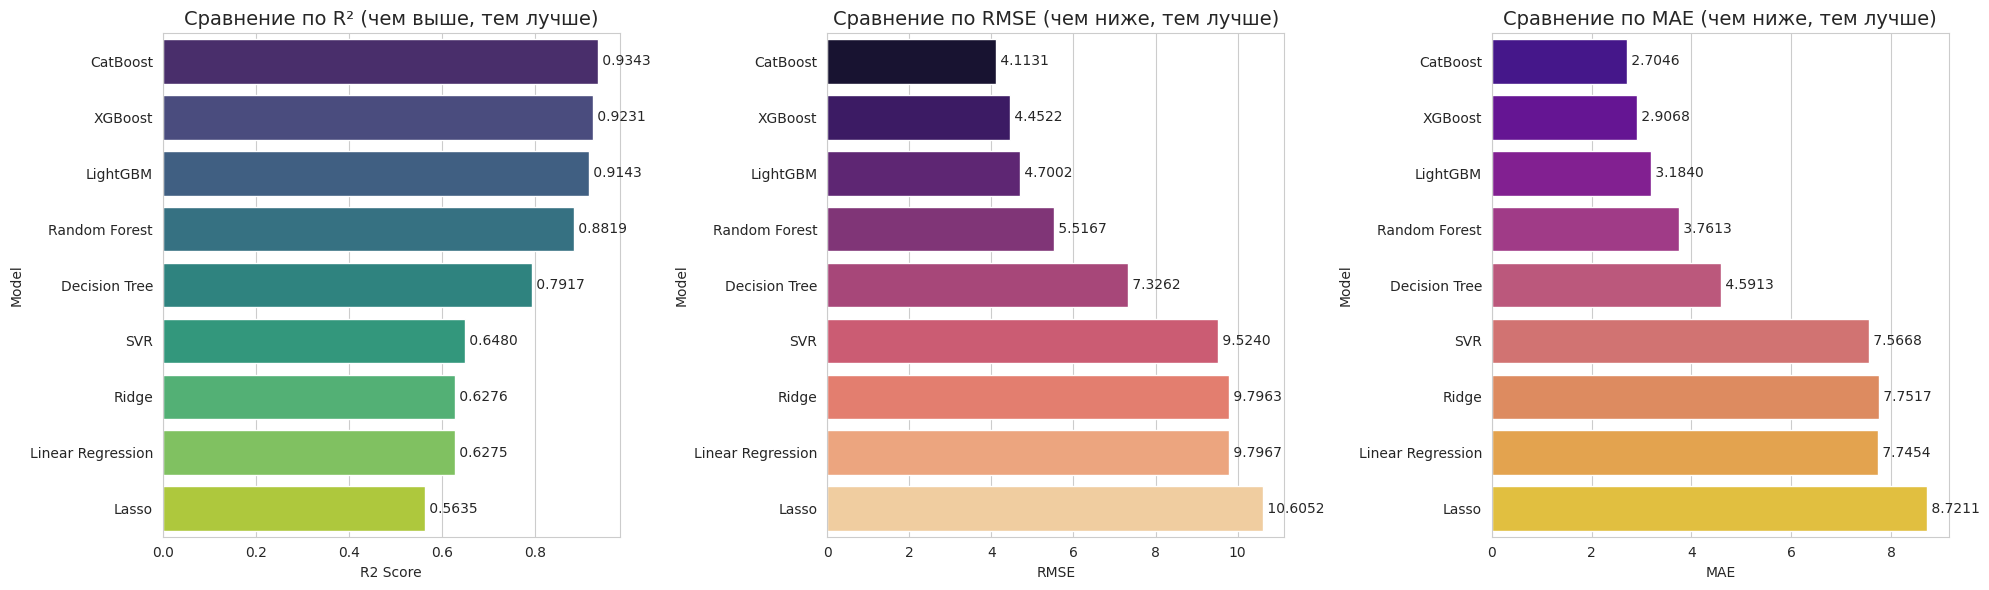

In [78]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(data=results_df, x='R2 Score', y='Model', palette='viridis', ax=axes[0])
axes[0].set_title('Сравнение по R² (чем выше, тем лучше)', fontsize=14)
for index, value in enumerate(results_df['R2 Score']):
    axes[0].text(value, index, f' {value:.4f}', va='center')

sns.barplot(data=results_df, x='RMSE', y='Model', palette='magma', ax=axes[1])
axes[1].set_title('Сравнение по RMSE (чем ниже, тем лучше)', fontsize=14)
for index, value in enumerate(results_df['RMSE']):
    axes[1].text(value, index, f' {value:.4f}', va='center')

sns.barplot(data=results_df, x='MAE', y='Model', palette='plasma', ax=axes[2])
axes[2].set_title('Сравнение по MAE (чем ниже, тем лучше)', fontsize=14)
for index, value in enumerate(results_df['MAE']):
    axes[2].text(value, index, f' {value:.4f}', va='center')

plt.tight_layout()
plt.show()


--- Лучшая модель: CatBoost (R² = 0.9343) ---


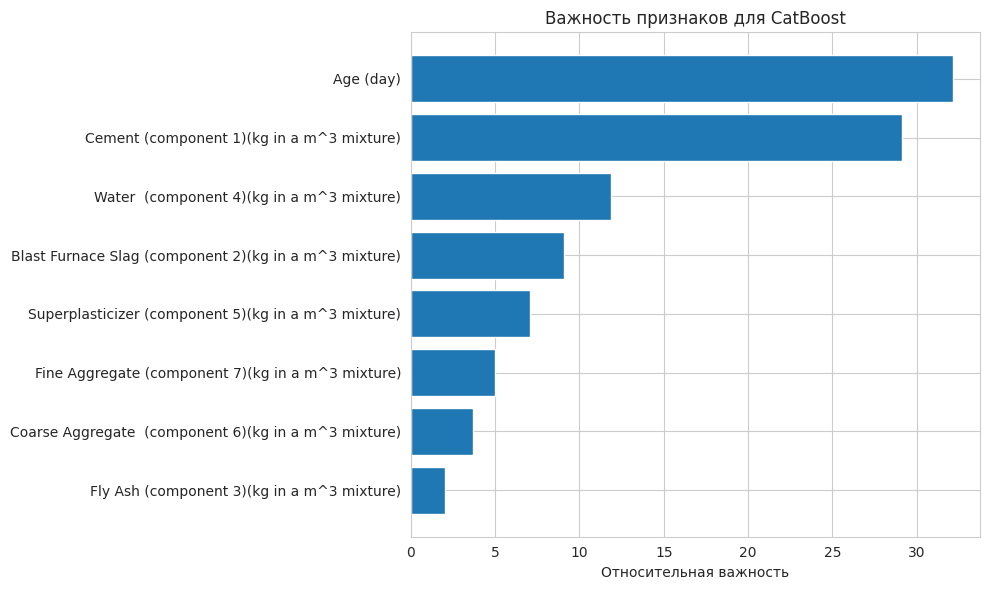

In [79]:
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['R2 Score']
print(f"\n--- Лучшая модель: {best_model_name} (R² = {best_r2:.4f}) ---")

best_model = models[best_model_name]
best_model.fit(X_train, y_train)

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title(f'Важность признаков для {best_model_name}')
    plt.barh(range(len(indices)), importances[indices], align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Относительная важность')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = best_model.coef_
    if len(coefs.shape) == 1:
        coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': coefs})
        coef_df = coef_df.sort_values(by='Coefficient', key=abs, ascending=False)
        print("\nКоэффициенты линейной модели:")
        print(coef_df)

In [80]:
final_predictions = best_model.predict(X_test)
submission = pd.DataFrame({
    'Id': range(len(final_predictions)),
    target_col: final_predictions
})

print("\nПример сабмишна (первые 10 строк):")
print(submission.head(10))
submission.to_csv('submission.csv', index=False)
print("\nФайл submission.csv успешно сохранён!")


Пример сабмишна (первые 10 строк):
   Id  Concrete compressive strength(MPa, megapascals) 
0   0                                         52.084961
1   1                                         43.670174
2   2                                         73.439786
3   3                                         33.726877
4   4                                         11.551350
5   5                                         46.270688
6   6                                         25.125317
7   7                                         48.518887
8   8                                         34.003682
9   9                                         44.574952

Файл submission.csv успешно сохранён!


In [81]:
print("\n" + "="*70)
print("ВЫВОДЫ")
print("="*70)
print(f"1. Лучшей моделью по метрике R² является **{best_model_name}** с результатом {best_r2:.4f}.")
print("2. Градиентный бустинг и Random Forest показали наилучшие результаты.")
print("3. Линейные модели оказались слабее из-за нелинейности данных.")
print("4. SVR с RBF-ядром показал средний результат.")
print(f"5. Модель **{best_model_name}** использована для создания файла submission.csv.")


ВЫВОДЫ
1. Лучшей моделью по метрике R² является **CatBoost** с результатом 0.9343.
2. Градиентный бустинг и Random Forest показали наилучшие результаты.
3. Линейные модели оказались слабее из-за нелинейности данных.
4. SVR с RBF-ядром показал средний результат.
5. Модель **CatBoost** использована для создания файла submission.csv.
